In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv('loan_approval_dataset.csv')

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


# EDE

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            491 non-null    str    
 1   Gender             481 non-null    str    
 2   Married            490 non-null    str    
 3   Dependents         482 non-null    str    
 4   Education          491 non-null    str    
 5   Self_Employed      462 non-null    str    
 6   ApplicantIncome    491 non-null    int64  
 7   CoapplicantIncome  491 non-null    float64
 8   LoanAmount         475 non-null    float64
 9   Loan_Amount_Term   478 non-null    float64
 10  Credit_History     448 non-null    float64
 11  Property_Area      491 non-null    str    
 12  Loan_Status        491 non-null    int64  
dtypes: float64(4), int64(2), str(7)
memory usage: 66.2 KB


In [6]:
df.shape

(491, 13)

In [7]:
g_mode = df['Gender'].mode()[0]
m_mode = df['Married'].mode()[0]
d_mode = df['Dependents'].mode()[0]
se_mode = df['Self_Employed'].mode()[0]
ch_mode = df['Credit_History'].mode()[0]
la_median = df['LoanAmount'].median()
lat_median = df['Loan_Amount_Term'].median()

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            491 non-null    str    
 1   Gender             481 non-null    str    
 2   Married            490 non-null    str    
 3   Dependents         482 non-null    str    
 4   Education          491 non-null    str    
 5   Self_Employed      462 non-null    str    
 6   ApplicantIncome    491 non-null    int64  
 7   CoapplicantIncome  491 non-null    float64
 8   LoanAmount         475 non-null    float64
 9   Loan_Amount_Term   478 non-null    float64
 10  Credit_History     448 non-null    float64
 11  Property_Area      491 non-null    str    
 12  Loan_Status        491 non-null    int64  
dtypes: float64(4), int64(2), str(7)
memory usage: 66.2 KB


In [9]:
df['Gender'] = df['Gender'].fillna(g_mode)                  # FILL THE ALL NULL VALUE BY MOD AND MEDIAN
df['Married'] = df['Married'].fillna(m_mode)
df['Dependents'] = df['Dependents'].fillna(d_mode)
df['Self_Employed'] = df['Self_Employed'].fillna(se_mode)
df['Credit_History'] = df['Credit_History'].fillna(ch_mode)
df['LoanAmount'] = df['LoanAmount'].fillna(la_median)
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(lat_median)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            491 non-null    str    
 1   Gender             491 non-null    str    
 2   Married            491 non-null    str    
 3   Dependents         491 non-null    str    
 4   Education          491 non-null    str    
 5   Self_Employed      491 non-null    str    
 6   ApplicantIncome    491 non-null    int64  
 7   CoapplicantIncome  491 non-null    float64
 8   LoanAmount         491 non-null    float64
 9   Loan_Amount_Term   491 non-null    float64
 10  Credit_History     491 non-null    float64
 11  Property_Area      491 non-null    str    
 12  Loan_Status        491 non-null    int64  
dtypes: float64(4), int64(2), str(7)
memory usage: 66.1 KB


In [11]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,360.0,1.0,Urban,1
4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


In [12]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

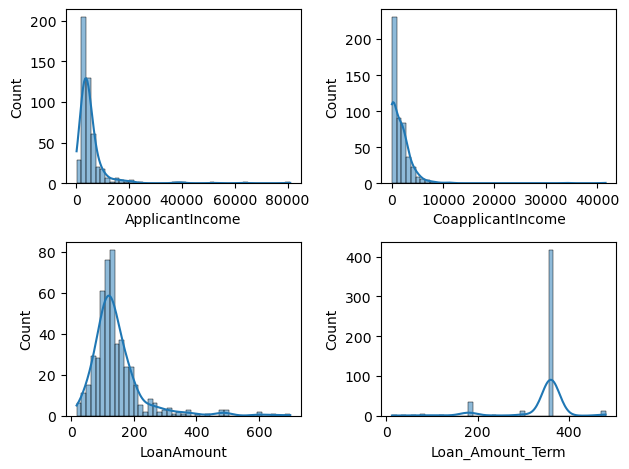

In [13]:
def plotting(var , num):
    plt.subplot(2,2,num)
    sns.histplot(df[var], kde=True)

plotting('ApplicantIncome', 1)
plotting('CoapplicantIncome', 2)
plotting('LoanAmount', 3)
plotting('Loan_Amount_Term', 4)

plt.tight_layout()

In [14]:
df['Dependents'].unique()

<ArrowStringArray>
['0', '3+', '2', '1']
Length: 4, dtype: str

In [15]:
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

In [16]:
df['Dependents'].unique()

array([0, 3, 2, 1])

In [17]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']   # FEATURE EXTRACTING
df['Income_Loan_Ratio'] = df['TotalIncome'] / df['LoanAmount']
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']

In [18]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Income_Loan_Ratio,EMI
0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1,4547.0,39.539130,0.319444
1,LP001715,Male,Yes,3,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1,5703.0,43.869231,0.361111
2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0,6784.0,61.672727,0.305556
3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,360.0,1.0,Urban,1,4695.0,48.906250,0.266667
4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1,8450.0,36.739130,0.766667


In [19]:
df_encode = df.drop('Loan_ID', axis=1)

In [20]:
df = pd.get_dummies(df,drop_first=True)
df_encode = pd.get_dummies(df_encode,drop_first=True)

In [21]:
df_encode = df_encode.astype(int)
df = df.astype(int)

In [22]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Income_Loan_Ratio,EMI,...,Loan_ID_LP002978,Loan_ID_LP002979,Loan_ID_LP002983,Loan_ID_LP002990,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,4547,0,115,360,1,1,4547,39,0,...,0,0,0,0,0,0,0,0,1,0
1,3,5703,0,130,360,1,1,5703,43,0,...,0,0,0,0,1,1,1,1,0,0
2,0,4333,2451,110,360,1,0,6784,61,0,...,0,0,0,0,0,1,0,0,0,1
3,0,4695,0,96,360,1,1,4695,48,0,...,0,0,0,0,1,1,1,1,0,1
4,2,6700,1750,230,300,1,1,8450,36,0,...,0,0,0,0,1,1,0,0,1,0


# MODEL MAKING

In [23]:
X = df_encode.drop('Loan_Status', axis= 1)
y = df_encode['Loan_Status']

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42,stratify=y)

In [26]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [27]:
from sklearn.model_selection import GridSearchCV

In [28]:
param_grid = {
    'n_estimators' : [100,200,300],
    'max_depth' : [None,10,20,30],
    'min_samples_split' : [2,5,10] , 
    'min_samples_leaf' : [1,2,4]
}

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
rf = RandomForestClassifier(random_state=42)


In [34]:
grid_search = GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,n_jobs=-1,verbose=2)
grid_search.fit(X_train_scaled,y_train)

best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [48]:
y_pred = best_rf.predict(X_test_scaled)

In [36]:
from sklearn.metrics import accuracy_score , classification_report

In [49]:
print(accuracy_score(y_test,y_pred))

0.8383838383838383


In [50]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.60      0.69        30
           1       0.84      0.94      0.89        69

    accuracy                           0.84        99
   macro avg       0.83      0.77      0.79        99
weighted avg       0.84      0.84      0.83        99



# DEPLOY

In [52]:
import joblib
joblib.dump(best_rf, 'loan_best_rf.pkl')      
joblib.dump(scaler, 'scaler.pkl')   
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']